Assignment2 - Project

The dataset may be found at: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

Oftentimes, a company that wants to sell/market some product will perform Customer Personality Analysis (CPA), an analysis that attempts to help the business understand customers better. With a greater understanding of customers, the organization can then work to adjust their products to appeal more to needs, behaviors, and concerns of consumers. Additionally, CPA deals with customer segmentation, so that the company can market to those specific segments in different ways, thus appealing to a broader number of people.

This data involves information on the individuals (year of birth, education level, marital status, etc.), products (amount spent on different food categories), promotions (the number of purchases made with a discount, as well as when the customer accepted a particular offer), and the number of purchases made by place (website, in-store, etc.). Our overall goals are to cluster the data into distinct customer groups and to build prediction models that determine whether a customer will respond to a campaign.

First, let's import the necessary packages and read in the data (note that the file path may need to be adjusted):

In [1]:
import csv
import sqlite3
import pandas as pd

In [2]:
import os
os.chdir('C:/ucf_classes/sta_5735')

In [3]:
cpa_data = pd.read_csv('marketing_campaign.csv', delimiter = "\t")

Before we work on our goals, we should clean the data and/or ensure that the variables are relevant. It would help to observe exactly what variables are in our dataset, as well as the type of data we're working with, how many observations there are, and how many null values there are.

In [4]:
cpa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

From this, we can see that the only column containing null values is the "income" column; twenty-four of the values are null. Because this is only a small fraction of our data, it would serve us well to remove the observations containing null values. 

In [5]:
cpa_data = cpa_data.dropna()

Now that we have our data completely cleaned, we should generate some summary statistics on our numerical variables:

In [6]:
sum_stats = cpa_data.describe()
sum_stats

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


There's a lot to be observed here. First, the 'ID' column, though an integer, offers no value in understanding any of the other variables. The data involves individuals with birth years ranging from 1893 to 1996, and of the observations, none of the consumers had more than two children/teens living in their home. The average number of days since a customer's last purchase is approximately 49 days with a standard deviation of approximately 29 days. We might note the difference between the average amounts spent on various products within the past two years -- Wines: $305, Fruits: $26, Meats: $167, Fish: $38, Sweets: $27, Gold: $44.

On average, consumers tend to make more purchases in store, with purchases online following and catalog purchases coming in last. On average, the company's website experienced about 5.32 visits in the past month. The "AcceptedCmpn" variables are all dummies, indicating if a customer accepted an offer/deal in the n-th campaign (with n ranging from 1 to 5), so a numerical interpretation cannot really be gained from these features. 'Response' indicates the same thing, except it is the final campaign the company attempted on its customers. 'Complaint' is also a dummy variable, equivalent to 1 if the customer complained in the last two years and 0 otherwise. Because the mean is fairly close to 0, we can see that the majority of customers did not complain over the specified time frame. 

'Z_CostContact' and 'Z_Revenue' are the exact same value across all observations; therefore, considering there is no variation whatsoever (as demonstrated by the standard deviation of 0), these two variables add no information to our dataset when it comes to segmenting customers and building prediction/regression models.

Noting this, let's remove the 'ID', 'Z_CostContact', and 'Z_Revenue' columns from our dataset.

In [7]:
cpa_data = cpa_data.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis = 1)

Next, we might perform a correlation analysis on our numerical values. This analysis might help in determining if our variables can be represented by a linear relationship.

In [8]:
correlation = cpa_data.drop(['Education', 'Marital_Status', 'Dt_Customer', 'Response', 'Complain', 'AcceptedCmp1',
                             'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], axis = 1).corr()

It might help to visualize our correlation matrix with a heatmap. The heatmap better emphasizes which variables have a positive versus negative correlation by utilizing a color scheme. 

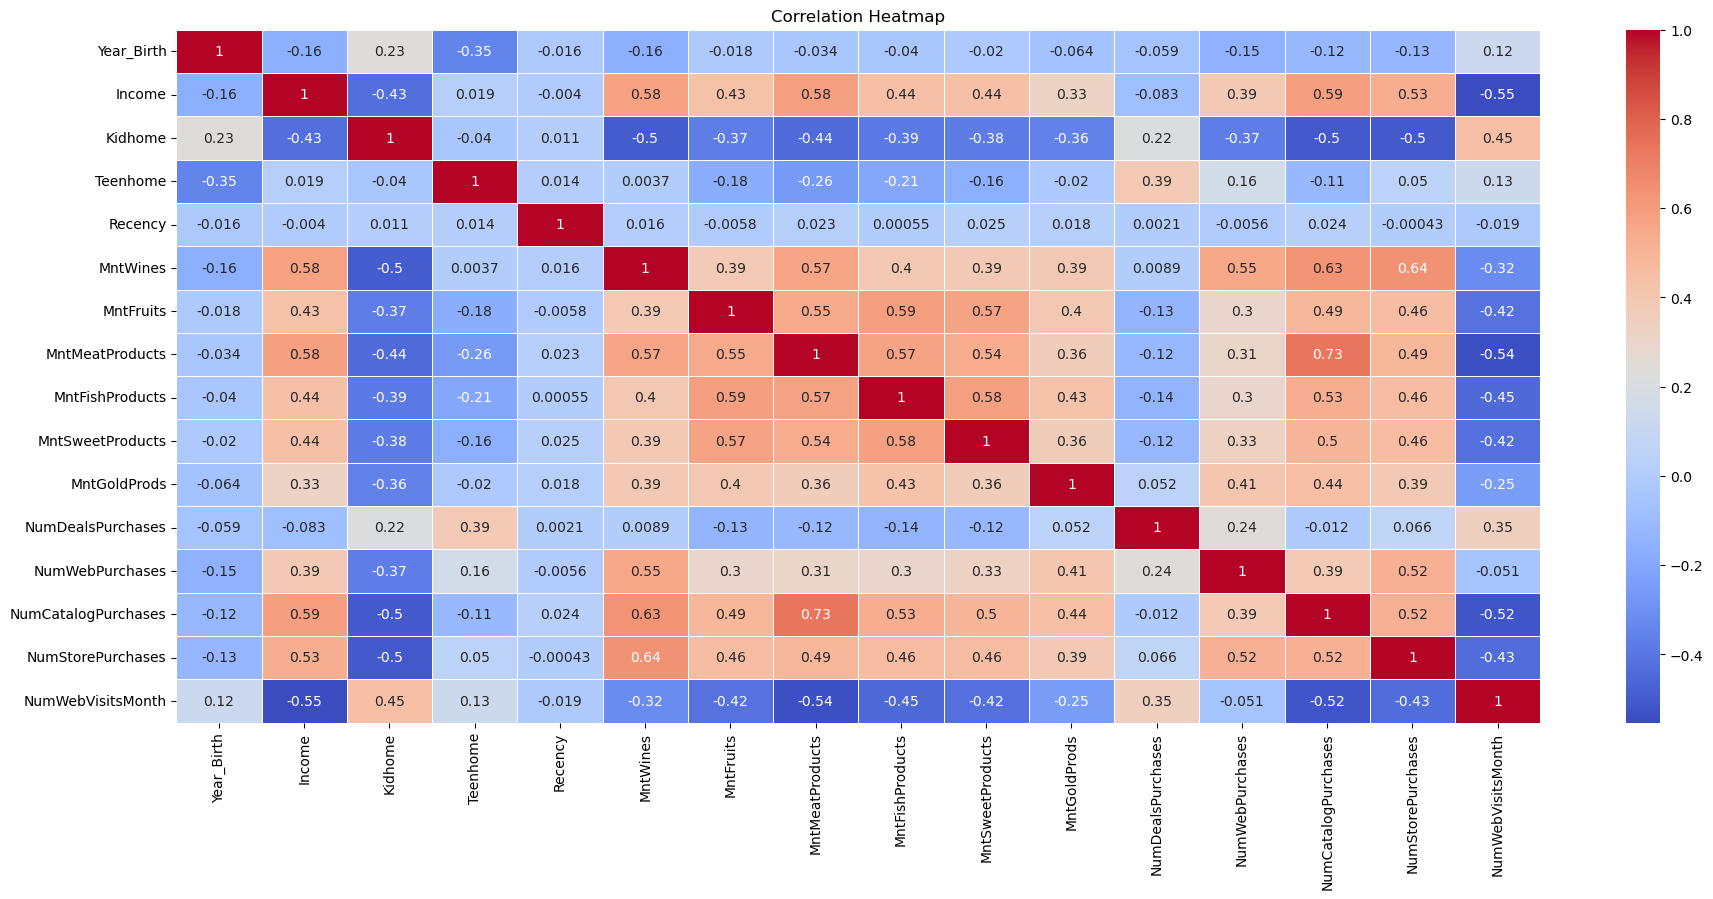

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,9))
sns.heatmap(correlation, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Looking at this visual, we can easily identify which variables have strong/weak correlations and whether those are positive or negative. Unsurprisingly, 'Income' has a positive correlation with the amount spent on different products ('MntWines', 'MntFruits', etc.), as well as the number of web purchases, catalog purchases, and store purchases. However, 'Income' is slightly negatively correlated with the number of purchases made with a discount ('NumDealsPurchases'), which makes sense; if one makes more money, he or she is less likely to be concerned with trying to save money.

The amount spent on a specific type of product is positively correlated with the amount spent on the other types of products. For example, the amount spent on meats has a correlation with the amount spent on fruits of +0.55. The number of purchases variables are also positively correlated with the amounts spent on different products. However, besides these and the ones mentioned previously, the remaining variables either have weak positive correlations (where the squares are filled with faded colors) or those correlations are negative. 

The negative correlations that stand out the most are 'Income' and 'NumWebVisitsMonth', 'NumWebVisitsMonth' and the variables involving the amount spent on products, 'Kidhome' and the variables involving the amount spent on products, 'Kidhome' and the variables involving the number of purchases, and 'NumWebVisitsMonth' and the variables involving the number of purchases.

Within our data, there are some non-numerical columns: 'Education', 'Marital_Status', and "Dt_Customer'. These variables indicate the customer's education level, the customer's marital status, and the date of the customer's enrollment with the company, respectively. Additionally, there are a few dummy variable columns ('AcceptedCmp1' - 'AcceptedCmp5', 'Response', and 'Complaint'). To learn more about these categories, we should create some bar charts and box plots.

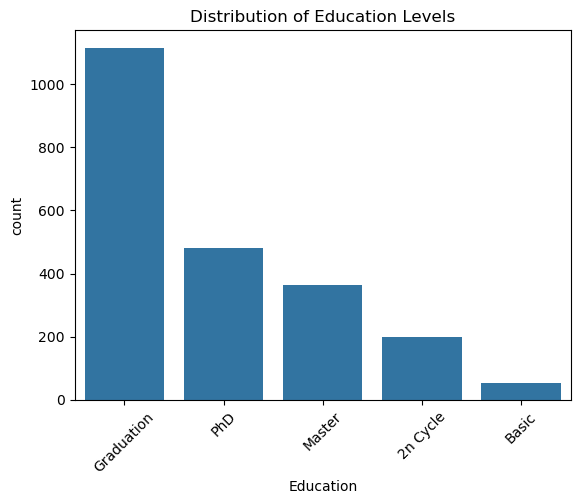

In [10]:
sns.countplot(x = cpa_data["Education"], order = cpa_data["Education"].value_counts().index)
plt.title("Distribution of Education Levels")
plt.xticks(rotation=45)
plt.show()

From the above plot, we have a better idea of the education levels of the consumers buying products from this organization, and it tells us how we might clean the data a bit. Because "2n Cycle" and "Master" essentially represent the same thing, we can merge these together.

In [11]:
cpa_data['Education'] = cpa_data['Education'].replace({'2n Cycle': 'Master'})

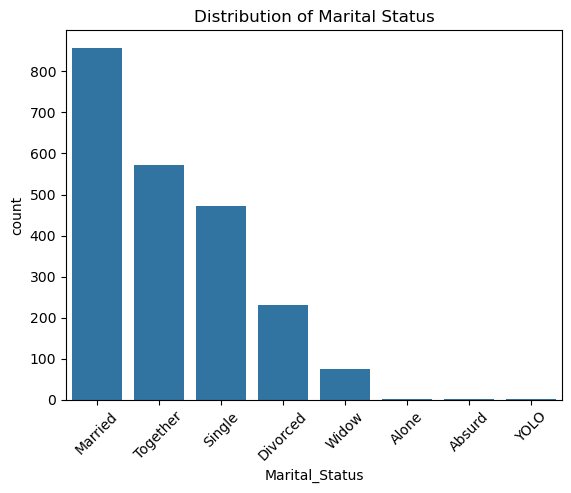

In [12]:
sns.countplot(x = cpa_data["Marital_Status"], order = cpa_data["Marital_Status"].value_counts().index)
plt.title("Distribution of Marital Status")
plt.xticks(rotation=45)
plt.show()

Similarly, there are a few values in the 'Marital_Status' column that could be edited. For the intents and purposes of this analysis, 'Single' and 'Alone' are essentially the same, so they may be combined as was done with the 'Education' column. Moreover, 'Absurd' and 'YOLO' do not make sense for this category, indicating that we should probably drop the observations containing those values (especially since there are so little of them). 

In [13]:
cpa_data['Marital_Status'] = cpa_data['Marital_Status'].replace({'Alone': 'Single'})

In [14]:
cpa_data = cpa_data.drop(cpa_data[cpa_data['Marital_Status'].isin(['YOLO', 'Absurd'])].index)

Additionally, we might observe how many customers within our dataset filed complaints:

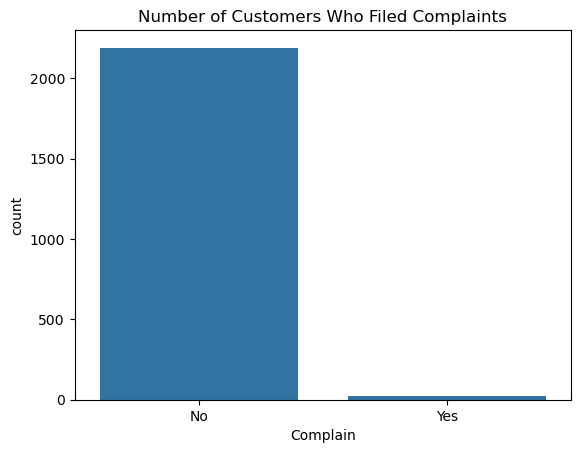

In [15]:
sns.countplot(x = cpa_data["Complain"])
plt.title("Number of Customers Who Filed Complaints")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()


From this, we note that only a relative few customers actually felt compelled enough to file a complaint against the company.

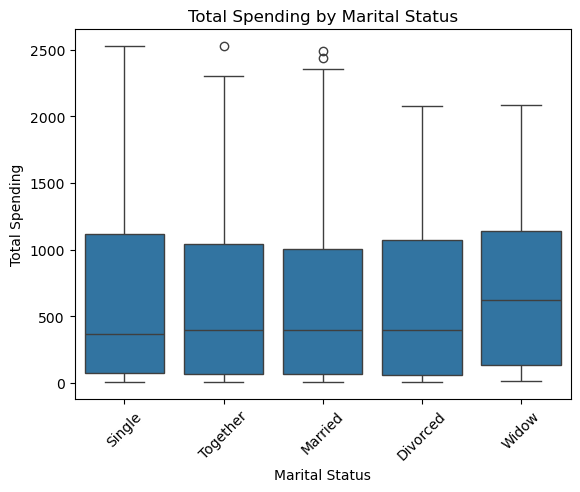

In [16]:
cpa_data["Total_Spending"] = cpa_data[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
sns.boxplot(x = cpa_data["Marital_Status"], y = cpa_data["Total_Spending"])
plt.title("Total Spending by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

The box plot above offers some insight as to how the relationship status of an individual impacts his/her spending. Overall, marital status does not seem to drastically change the spending habits of customers, though the median spending of the widow differs somewhat from the other categories. The spending range across all categories is wide, so spending habits definitely vary significantly amongst each group. Moreover, a few outliers in the 'Together' and "Married' columns demonstrate that a few customers spend a good amount more than others on products, which makes them potentially good targets for marketing campaigns.

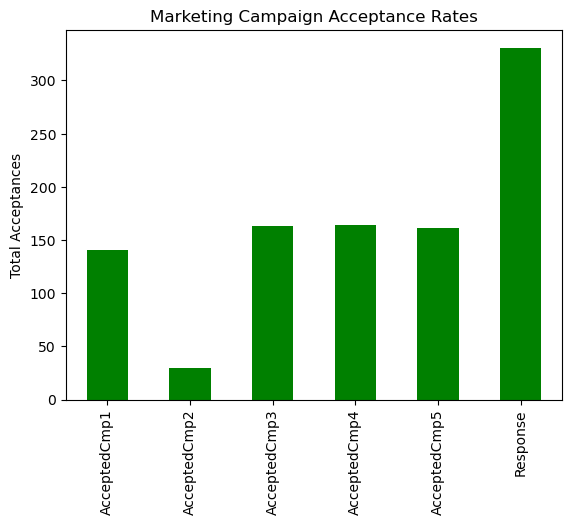

In [17]:
cpa_data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum().plot(kind="bar", color="green")
plt.title("Marketing Campaign Acceptance Rates")
plt.ylabel("Total Acceptances")
plt.show()


The above plot allows us to observe the effectiveness of campaigning/which campaigns were most successful. As shown, the 'Response' category has over double the amount of acceptances, so clearly some individuals who were not willing to accept any of the offers from the first five campaigns accepted the final offer. Campaign #2 appears to have done significantly worse than the other five.

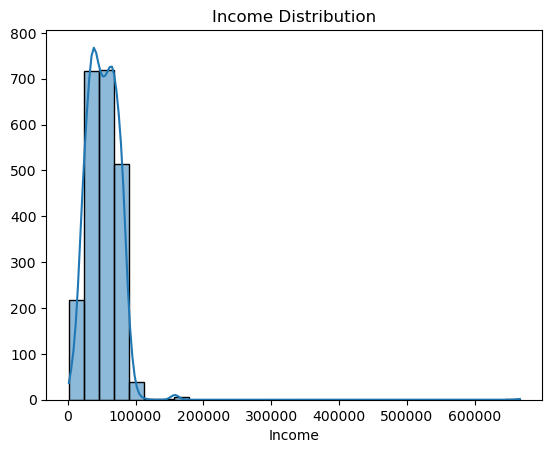

In [18]:
sns.histplot(cpa_data["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.ylabel("")
plt.show()

In this visualization of the income distribution, there is a very noticable outlier affecting our data. For this analysis, let's remove this observation as well and then reobserve the density function/histogram of 'Income'. 

In [19]:
cpa_data = cpa_data.drop(cpa_data['Income'].idxmax())

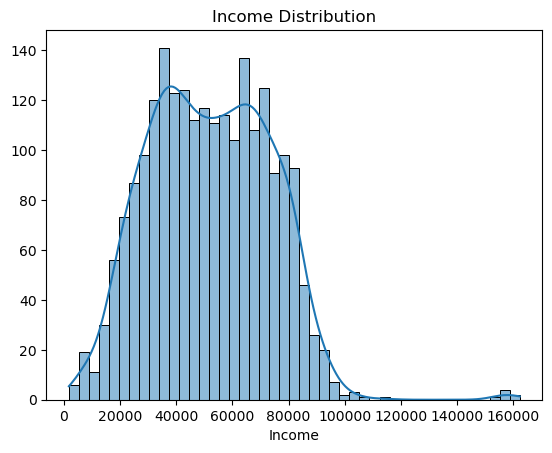

In [20]:
sns.histplot(cpa_data["Income"], bins=45, kde=True)
plt.title("Income Distribution")
plt.ylabel("")
plt.show()

The first thing to note is that this distribution is right-skewed, suggesting that the majority of people earn a low-to-medium level of income, with only a smaller amount of people earning large salaries. Second, there are a couple obvious peaks (one around $40,000 and one around $70,000).

Having explored and summarized the data, we might now work on our first goal: Clustering. The most commonly used form of clustering is known as K-means, which groups data points into a specified number of clusters where each point belongs to a cluster with the closest mean. This partitioning of the data minimizes the variance within each cluster. In K-means clustering, there are two types of techniques often used to determine the optimal number of clusters. We will utilize the elbow method, which plots the sum of the squared distances of the data points to their nearest centroid (mean) against the number of clusters. It is easy to interpret and visualize, as well as computationally inexpensive.

Since K-means is a numerical measure, we should first take our string variables ('Education', 'Marital_Status', and 'Dt_Customer') and convert them into categorical/dummy variables so that they can still be utilized in this process. Furthermore, we might convert the date the customer enrolled in the company into a different variable specifying how many days the customer has been part of the company in comparison to the latest date.

In [21]:
cpa_encoded = pd.get_dummies(cpa_data, columns = ['Education', 'Marital_Status'], drop_first = False)

cpa_encoded['Dt_Customer'] = pd.to_datetime(cpa_encoded['Dt_Customer'], format='%d-%m-%Y')
last_date = cpa_encoded['Dt_Customer'].max()
cpa_encoded['DaysInCompany'] = (last_date - cpa_encoded['Dt_Customer']).dt.days

cpa_encoded = cpa_encoded.drop(columns = ['Dt_Customer'])
cpa_encoded = cpa_encoded.astype(int)

Now, we can utilize all the variables in our cpa_encoded dataset for K-means clustering. Standardizing the data is necessary, to ensure all our variables are measured on the same scale. We will explore a range of 1 to 10 clusters and use the KMeans() function found in the sklearn package.

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

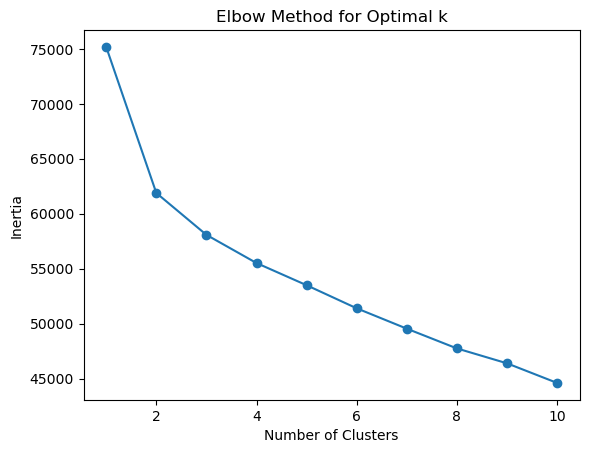

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cpa_encoded)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 50)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

We can pair the elbow method with the silhouette score, which is more robust and would help in identifying an optimal number of clusters. The silhouette score evaluates the quality of the clustering by measuring how similar each point is to its own cluster compared to other clusters. This score ranges from -1 to +1, with a higher score translating to better-defined cluster and scores close to 0 specifying that the clusters are poorly defined. Negative values indicate that the samples may be misclassified.

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

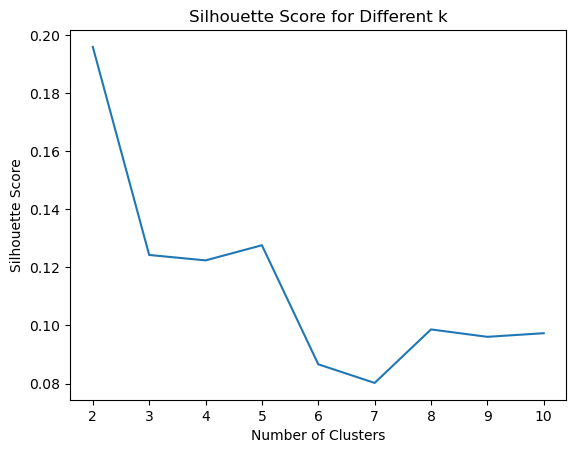

In [23]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, n_init = 50, random_state = 42)
    kmeans.fit(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


The score for two clusters is the highest, somewhere between .19 and .2, which is not ideal. We would prefer a higher score, so we may need to adjust which variables are included in the K-means process, or use a completely different clustering process. One way to try and fix a low silhouette score is to reduce the dimensions of our data while still keeping a good amount of the variance. Principal Component Analysis (PCA) identifies the most relevant features with the most variance; the principal components are linear combinations of the original variables, but they are now uncorrelated. Using PCA:

In [24]:
import numpy as np
from sklearn.decomposition import PCA

Let's begin with trying to maintain 95% variance:

In [25]:
pca = PCA()
pca.fit(scaled_data)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(cum_var)

[0.22570643 0.29095077 0.34906043 0.40180025 0.44702345 0.49176251
 0.53186195 0.568199   0.60366674 0.63582691 0.66790039 0.69785557
 0.72707731 0.75530154 0.77947839 0.80278928 0.8241319  0.84461728
 0.86242437 0.87942495 0.89604915 0.91154183 0.9262227  0.9387587
 0.95084085 0.96219361 0.97302031 0.98199358 0.98888068 0.99511561
 1.         1.         1.         1.        ]


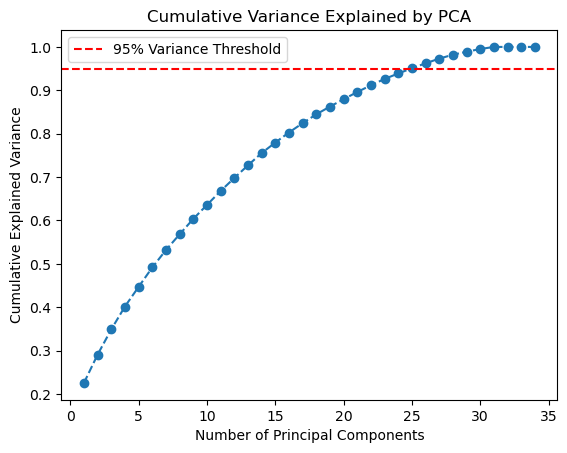

In [26]:
plt.plot(range(1, len(cum_var) + 1), cum_var, marker = 'o', linestyle = '--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained by PCA')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.show()

Therefore, we should see if performing K-means on dimension-reduced data helps with the clustering process. From the above plot, maintaining 95% variance means keeping the first 25 of our principal components, so we'll begin with that.

In [27]:
pca = PCA(n_components = 25)
reduced_features = pca.fit_transform(scaled_data)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

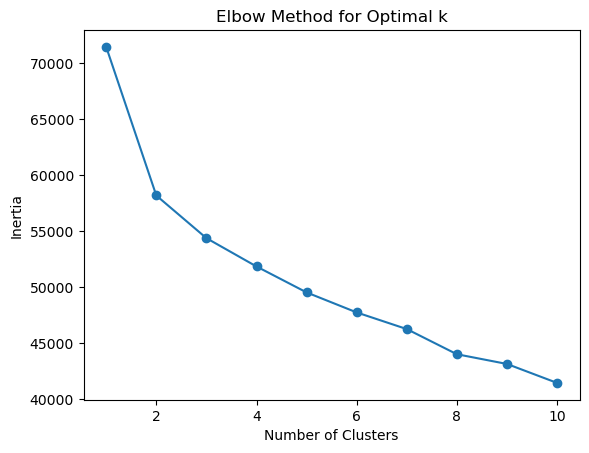

In [28]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 50)
    kmeans.fit(reduced_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

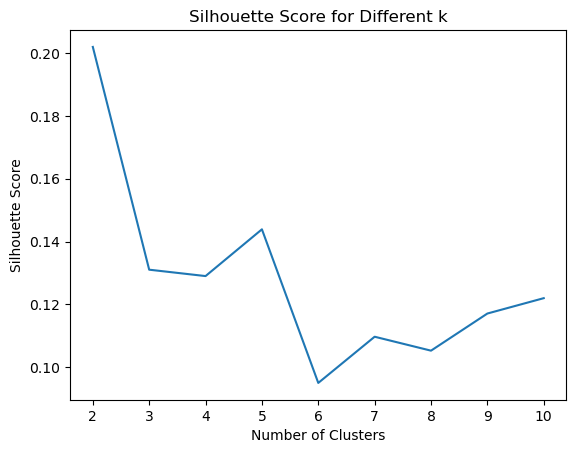

In [29]:
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, n_init = 50, random_state = 42)
    kmeans.fit(reduced_features)
    silhouette_avg = silhouette_score(reduced_features, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

The score did improve somewhat, but only slightly. Furthermore, two is still the optimal number of clusters, even with the reduced dimensionality. We can visualize this, but K-means may not necessarily be the best method for clustering.

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


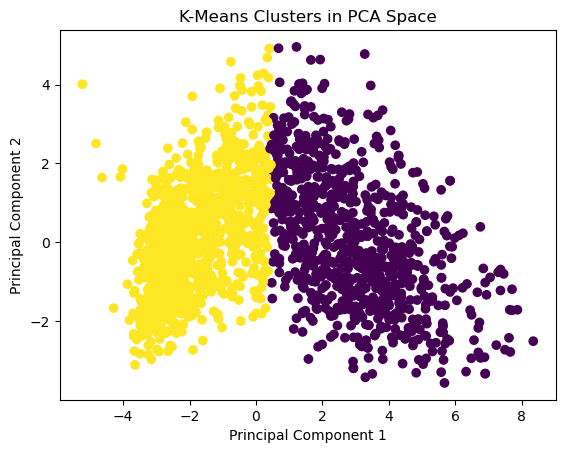

In [30]:
kmeans = KMeans(n_clusters = 2, random_state=42, n_init=50)
labels = kmeans.fit_predict(reduced_features)

plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c = labels, cmap = 'viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters in PCA Space')
plt.show()

The data appears somewhat elongated, so we'll try a Gaussian Mixture Model instead of K-means, as GMM attempts to fit ellipses while K-means works with spherical clusters.

In [31]:
from sklearn.mixture import GaussianMixture

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels_gmm = gmm.fit_predict(reduced_features)
    silhouette = silhouette_score(reduced_features, labels_gmm)
    print(f"Silhouette score for {k} clusters: {silhouette}")


c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette score for 2 clusters: 0.17890361289089168
Silhouette score for 3 clusters: 0.1123564219075171


c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette score for 4 clusters: 0.0549043760537102


c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


...

Silhouette score for 8 clusters: 0.06667233479458819


c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette score for 9 clusters: 0.07173936588777367


c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette score for 10 clusters: 0.05891539498037055


The silhouette score using GMM doesn't improve at all, so GMM is probably not a good fit for clustering our data either. Another alternative to try is DBSCAN, which is a density-based clustering algorithm focused on grouping data points by density, establishing clusters based on the density of a region (separating the clusters by low-density areas), and marking outliers as noise. This method does not assume any particular shape of the clusters, and due to its handling of outliers (not classifying them within any cluster) it is a robust mechanism. 

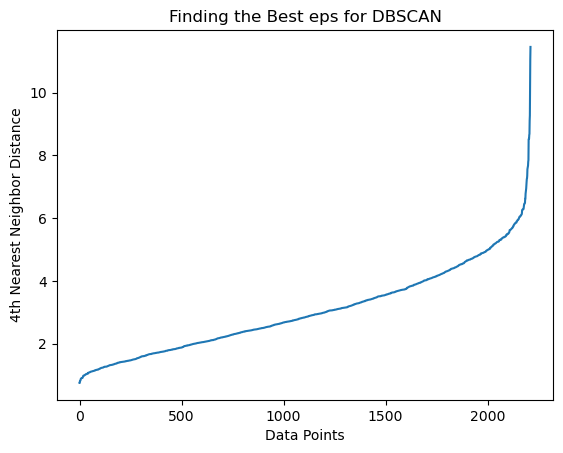

In [32]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors = 5).fit(reduced_features)
distances, indices = neighbors.kneighbors(reduced_features)
distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("Finding the Best eps for DBSCAN")
plt.show()

In [33]:

from scipy.spatial.distance import cdist

def find_elbow(distances):
    dist_diff = np.diff(distances)
    elbow_index = np.argmax(dist_diff)
    return distances[elbow_index]

best_eps = find_elbow(distances)
print(f"Recommended eps: {best_eps}")

Recommended eps: 9.268458288918355


From the above function and plot, we can observe what the optimal eps is. Eps refers to 'epsilon', the radius in which neighbors are considered. Using the above value in our DBSCAN process:

In [34]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = best_eps, min_samples = 5)
labels_dbscan = dbscan.fit_predict(reduced_features)

In [35]:
unique_labels = np.unique(labels_dbscan)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
print(f"Number of clusters (excluding noise): {num_clusters}")

Number of clusters (excluding noise): 2


From this, we see that DBSCAN also determines two is the number of clusters our data may be split in to. We can determine the size of each cluster, done below.

In [36]:
cluster_sizes = {label: np.sum(labels_dbscan == label) for label in unique_labels}
cluster_sizes = {label: size for label, size in cluster_sizes.items() if label != -1}

print("Cluster Sizes (excluding noise):")
for label, size in cluster_sizes.items():
    print(f"Cluster {label}: {size} points")


Cluster Sizes (excluding noise):
Cluster 0: 2190 points
Cluster 1: 21 points


Additionally, let's plot the two clusters:

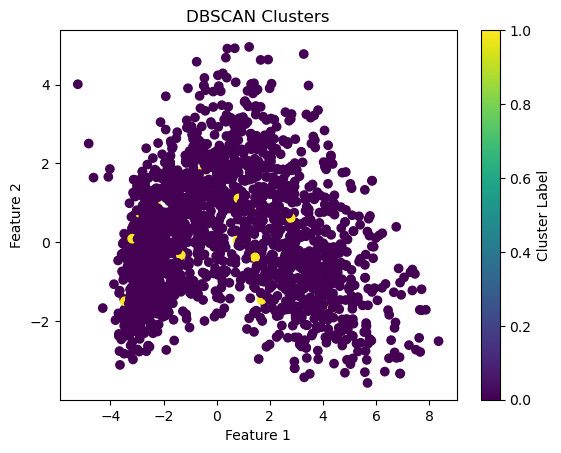

In [37]:
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels_dbscan, cmap='viridis', marker='o')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clusters")
plt.colorbar(label='Cluster Label')
plt.show()

Considering only 21 points are contained in our second cluster out of 2,211 data points, I conclude that this data is just not very clusterable. Having utilized three different methods involving clustering (K-means, GMM, and DBSCAN), I cannot confidently say that, given the variables in this dataset and the specific observations, the company can easily cluster their customers to better market toward them.

There are a few potential reasons for this. Data points that are too evenly spread (or randomly spread) may not be easy to group together distinctly. Alternatively, the clusters generated by these processes may be too similar/close to each other, making it difficult for any clustering algorithm to do a good job.

Something else that might affect the results are the features we use. While I ran Principal Component Analysis to keep 95% variance in my data, there were still a large number of features being utilized. Thus, the dimensionality could not be reduced significantly without getting rid of a lot of variability. Had I continued to bring down the number of features, there would have been a heavy loss of important information that really allows for distinguishing patterns within the data. Furthermore, using too few principal components could oversimplify the data and lead to underfitting.

Moving on to our next goal of predicting whether a customer will respond to a marketing campaign or not, we will use binary classification methods, identifying customers who would respond to the offer as 1s and those who wouldn't respond to a certain offer as 0s (as they are already classified in our dataset). Then we'll evaluate the accuracy of the predictions.

First, let's note that we have six "acceptance of offer" columns: 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', and 'Response' ('Response' is essentially a response to the sixth/final campaign). We can work on predicting each of these. Also, instead of looking at each column, it might serve us well to predict whether a consumer will accept any offer at all.

Beginning with 'AcceptedCmp1' (which is the first campaign and thus already independent of whether or not an individual will accept an offer in the future), we should first establish the variables we will use for prediction:

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, auc

In [39]:
y1 = cpa_encoded['AcceptedCmp1']
X1 = cpa_encoded.drop(columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'])

Splitting this data up into 75% training and 25% testing data:

In [40]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size = 0.25, random_state = 42
)

scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

Running logistic regression:

In [41]:
log_reg1 = LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = 42)
log_reg1.fit(X1_train_scaled, y1_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
y1_pred = log_reg1.predict(X1_test_scaled)
accuracy1 = accuracy_score(y1_test, y1_pred)
print(f"Logistic Regression Accuracy: {accuracy1:.5f}")

Logistic Regression Accuracy: 0.92948


Right off the bat, we observe a very high accuracy of approximately 92%. Let's look at a confusion matrix to see where the shortfalls are.

In [43]:
cm1 = confusion_matrix(y1_test, y1_pred)
print("Confusion Matrix:\n", cm1)

Confusion Matrix:
 [[509  14]
 [ 25   5]]


This model correctly predicted 509 observations as negative and 5 as positive. However, 14 of the observations that were negative were identified as positive by our model, and 25 of the observations that were positive were identified as negative. Seeing the disparity between the number of positive observations versus negative ones, it doesn't really come as a surprise that we obtained such a great accuracy. The false positives and false negatives are relatively small, supporting the idea that the negative class is more prevalent. This will certainly come up in our other predictions as well.

Repeating this process with 'AcceptedCmp2':

In [44]:
y2 = cpa_encoded['AcceptedCmp2']
X2 = cpa_encoded.drop(columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size = 0.25, random_state = 42
)

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

log_reg2 = LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = 42)
log_reg2.fit(X2_train_scaled, y2_train)

y2_pred = log_reg2.predict(X2_test_scaled)
accuracy2 = accuracy_score(y2_test, y2_pred)
print(f"Logistic Regression Accuracy: {accuracy2:.5f}")

Logistic Regression Accuracy: 0.98011


The accuracy on this column was even greater, approximately 98%. Let's look at the confusion matrix.

In [45]:
cm2 = confusion_matrix(y2_test, y2_pred)
print("Confusion Matrix:\n", cm2)

Confusion Matrix:
 [[542   1]
 [ 10   0]]


This model correctly predicted 542 observations as negative; however, none of the positive observations were correctly classified. Also, 1 of the observations that was negative was identified as as positive by our model, and 10 of the observations there were positive were incorrectly classified as negative. 

Repeating this for 'AcceptanceCmp3':

In [46]:
y3 = cpa_encoded['AcceptedCmp3']
X3 = cpa_encoded.drop(columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'])

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size = 0.25, random_state = 42
)

scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

log_reg3 = LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = 42)
log_reg3.fit(X3_train_scaled, y3_train)

y3_pred = log_reg3.predict(X3_test_scaled)
accuracy3 = accuracy_score(y3_test, y3_pred)
print(f"Logistic Regression Accuracy: {accuracy3:.5f}")

Logistic Regression Accuracy: 0.90778


This column was predicted less accurately than the previous two. The accuracy rate is about 91%, which is still pretty good. Observing the confusion matrix:

In [47]:
cm3 = confusion_matrix(y3_test, y3_pred)
print("Confusion Matrix:\n", cm3)

Confusion Matrix:
 [[501   4]
 [ 47   1]]


We're seeing a pattern with these predictions. Because the data is imbalanced, the models are not identifying the positive values as well as they could be. Noting this, instead of continuing with binary logistic regression, let's use decision trees on column three. A decision tree begins with an initial question about a feature within a dataset, then branches out based on the responses to another "leaf" (question), where the process continues until a final classification is reached.

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
dt_model3 = DecisionTreeClassifier(random_state = 42)
dt_model3.fit(X3_train_scaled, y3_train)

y3_pred_dt = dt_model3.predict(X3_test_scaled)
accuracy3_dt = accuracy_score(y3_test, y3_pred_dt)
print(f"Decision Tree Accuracy: {accuracy3_dt:.5f}")

Decision Tree Accuracy: 0.88246


In [50]:
cm3_dt = confusion_matrix(y3_test, y3_pred_dt)
print("Confusion Matrix:\n", cm3_dt)

Confusion Matrix:
 [[471  34]
 [ 31  17]]


Using decision trees, the accuracy actually decreased from 91% to 88%. Looking at the confusion matrix, we see that the true positive rate increased, as 17 positive values were correctly identified compared to just 1. However, the true negative rate increased as 34 of the negative values were classified as positive compared to 4. 

Another method we could utilize to try and improve the accuracy is a support vector machine, which finds the best "decision boundary" to separate different classes. It tends to be effective with datasets containing many features and it is robust to overfitting, so let's attempt this on our third acceptance column.

In [51]:
from sklearn.svm import SVC

In [52]:
svm_model3 = SVC(kernel='rbf', probability=True, random_state=42)
svm_model3.fit(X3_train_scaled, y3_train)

y3_pred_svm = svm_model3.predict(X3_test_scaled)
accuracy3_svm = accuracy_score(y3_test, y3_pred_svm)
print(f"SVM Accuracy: {accuracy3_svm:.5f}")

SVM Accuracy: 0.91320


The accuracy of our third column increased somewhat using a SVM compared to both logistic regression and decision trees. Looking at the confusion matrix:

In [53]:
cm3_svm = confusion_matrix(y3_test, y3_pred_svm)
print("Confusion Matrix:\n", cm3_svm)

Confusion Matrix:
 [[505   0]
 [ 48   0]]


Unfortunately, though the model did not incorrectly predict any negative cases as positive (as seen in the top right corner), it incorrectly classified 48 positive cases as negative. The accuracy is highly misleading, as the sensitivity is 0%. There is an argument for support vector machine learning called "class-weight", where we can tell the model to put more focus on the minority class. Trying this:

In [54]:
svm_model3 = SVC(kernel = 'rbf', probability = True, random_state = 42, class_weight = 'balanced')
svm_model3.fit(X3_train_scaled, y3_train)

y3_pred_svm = svm_model3.predict(X3_test_scaled)
accuracy3_svm = accuracy_score(y3_test, y3_pred_svm)
print(f"SVM Accuracy: {accuracy3_svm:.5f}")

SVM Accuracy: 0.82278


In [55]:
cm3_svm = confusion_matrix(y3_test, y3_pred_svm)
print("Confusion Matrix:\n", cm3_svm)

Confusion Matrix:
 [[425  80]
 [ 18  30]]


This model does a much better job at predicting the true positive values at the expense of misclassifying negative values, similar to the decision tree model. This SVM accuracy of about 82% is less than what we previously calculated, but it might serve better for determining some of the customers who will accept an offer. We should also try random forest, which combines decision trees, aggregating the individual trees' predictions.   

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
rf3_model = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced')
rf3_model.fit(X3_train_scaled, y3_train)

y3_pred_rf = rf3_model.predict(X3_test_scaled)
accuracy3_rf = accuracy_score(y3_test, y3_pred_rf)
print(f"Random Forest Accuracy: {accuracy3_rf:.5f}")

Random Forest Accuracy: 0.92948


In [58]:
cm3 = confusion_matrix(y3_test, y3_pred_rf)
print("Confusion Matrix:\n", cm3)

Confusion Matrix:
 [[504   1]
 [ 38  10]]


The accuracy of this model is about 93%, but as we've seen before, it is primarily due to the model's bias toward the majority class of 0s. Something else to try is to synthetically oversample of the minority class to balance the dataset. This can be accomplished with the SMOTE (Synthetic Minority Over-sampling Technique) algorithm.

In [59]:
from imblearn.over_sampling import SMOTE

In [60]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X3_train_scaled, y3_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [61]:
y3_pred_rf = rf.predict(X3_test_scaled)
accuracy3_rf = accuracy_score(y3_test, y3_pred_rf)
print(f"Random Forest Accuracy: {accuracy3_rf:.5f}")

Random Forest Accuracy: 0.92405


Here, we see that the accuracy went down by about .5% from when just using random forest on the imbalanced dataset.

In [62]:
cm3 = confusion_matrix(y3_test, y3_pred_rf)
print("Confusion Matrix:\n", cm3)

Confusion Matrix:
 [[497   8]
 [ 34  14]]


As seen above, 497 of the negative values and 14 of the positive values were classified correctly, with our model misclassifying 34 of the 1s as 0s and 8 of the 0s as 1s. Therefore, even this sampling method to better balance the dataset only improved our model on the 'AcceptedCmp3' column slightly. 

Because of the heavy imbalance in the dataset for each variable we are trying to predict up to this point, predicting whether each specific campaign will impact a customer is not going very well. Therefore, let's move on to our final goal of predicting whether a customer will respond to any of the campaigns. We can create a new column, where the rows are filled with ones and zeros dependent on if the customers in our dataset accepted the offer after any of the campaigns (not just a particular one).

First, let's create the column:

In [63]:
cpa_encoded['AcceptedAny'] = cpa_encoded[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                                          'AcceptedCmp4', 'AcceptedCmp5', 'Response']].apply(lambda row: 1 if row.any() else 0, axis=1)

Having done this, let's observe the balance (or imbalance) of our dataset now.

In [64]:
counts = cpa_encoded['AcceptedAny'].value_counts()
print(counts)

AcceptedAny
0    1608
1     603
Name: count, dtype: int64


Therefore, throughout the entire dataset, only 603 of the 2,211 customers accepted an offer after any of the campaigns, total. This is still imbalanced, but it does show how even more imbalanced the individual columns for each campaign were. Considering SVM did the best at classifying positives accurately for the 'AcceptedCmp3' column, let's begin with that to predict our 'AcceptedAny' column.

In [65]:
y_any = cpa_encoded['AcceptedAny']
X_any = cpa_encoded.drop(columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'])

X_any_train, X_any_test, y_any_train, y_any_test = train_test_split(
    X_any, y_any, test_size = 0.25, random_state = 42
)

scaler = StandardScaler()
X_any_train_scaled = scaler.fit_transform(X_any_train)
X_any_test_scaled = scaler.transform(X_any_test)

In [66]:
svm_model_any = SVC(kernel = 'rbf', probability = True, random_state = 42, class_weight = 'balanced')
svm_model_any.fit(X_any_train_scaled, y_any_train)

y_any_pred_svm = svm_model_any.predict(X_any_test_scaled)
accuracy_any_svm = accuracy_score(y_any_test, y_any_pred_svm)
print(f"SVM Accuracy: {accuracy_any_svm:.5f}")

SVM Accuracy: 0.99819


In [67]:
cm_any_svm = confusion_matrix(y_any_test, y_any_pred_svm)
print("Confusion Matrix:\n", cm_any_svm)

Confusion Matrix:
 [[396   0]
 [  1 156]]


This model did a significantly better job at predicting, despite the imbalance. Only one observation was misclassified as a non-accepting offer when, in fact, the customer did accept. 

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_any_test, y_any_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       396
           1       1.00      0.99      1.00       157

    accuracy                           1.00       553
   macro avg       1.00      1.00      1.00       553
weighted avg       1.00      1.00      1.00       553



We might also plot a Receiver Operating Characteristic (ROC) curve, which visualizes the true positive rate versus the false positive rate. Naturally since there were no false positives, we should see an area under the curve of 1 with the ROC curve actually consisting of a 90 degree angle.

In [69]:
from sklearn.metrics import roc_curve, auc

In [70]:
y_any_prob_svm = svm_model_any.predict_proba(X_any_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_any_test, y_any_prob_svm)
roc_auc = auc(fpr, tpr)

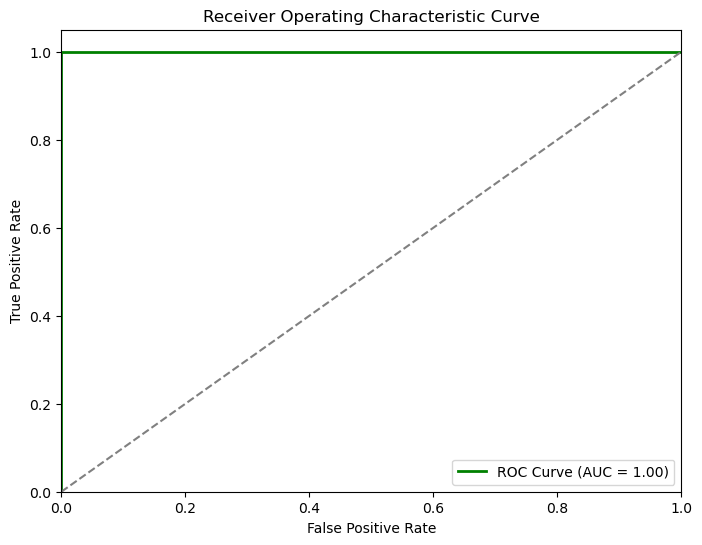

In [71]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc='lower right')
plt.show()

In conclusion, though we were unable to cluster our customers into distinct segments, we still ended up with a model that has great accuracy [(true negative + true positive)/total observations], precision [positive predictive value, true positive/(true positive + false positive)] , sensitivity [true positive rate, true positive/(true positive + false negative)], and specificity [true negative rate, true negative/(true negative + false positive)]. The almost perfect scores could indicate that the model is overfitting to this data set and thus might not generalize to new data. This would be something for the company to test in the future after accumulating more data. Another thing to note is that it was significantly more difficult to accurately determine which consumers would accept an offer based on a particular campaign compared to whether they would accept any offer at some time. Therefore, at this time, it would be better for the company to just target customers who they believe would respond to any campaign.